In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv("f1_clean.csv")

FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']
df = df.dropna(subset=FEATURES).reset_index(drop=True)
X = df[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset ready: {X_scaled.shape}")


Dataset ready: (5302, 4)


In [6]:
MIN_SAMPLES = 2 * len(FEATURES)   # = 8

print(f"Number of features : {len(FEATURES)}")
print(f"min_samples chosen : {MIN_SAMPLES}  (rule of thumb: 2 × n_features)")
print()


Number of features : 4
min_samples chosen : 8  (rule of thumb: 2 × n_features)



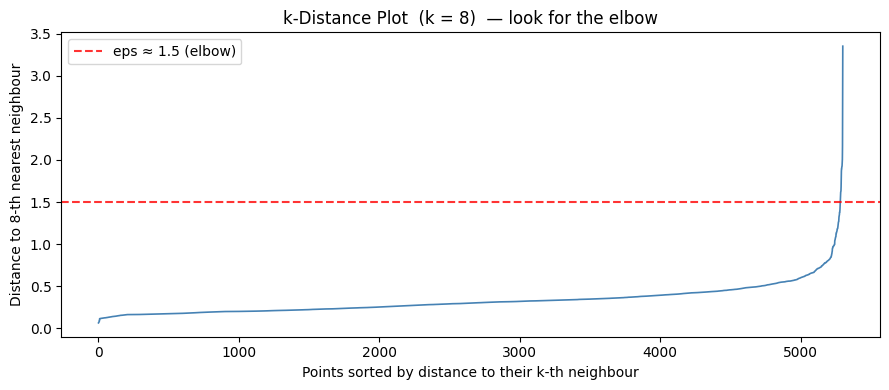

Saved: kdistance_plot.png



In [7]:
k = MIN_SAMPLES

nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_scaled)

distances, _ = nbrs.kneighbors(X_scaled)

k_distances = np.sort(distances[:, k])   # distances to k-th neighbour, sorted

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, linewidth=1.2, color='steelblue')
ax.set_xlabel("Points sorted by distance to their k-th neighbour")
ax.set_ylabel(f"Distance to {k}-th nearest neighbour")
ax.set_title(f"k-Distance Plot  (k = {k})  — look for the elbow")

ax.axhline(y=1.5, color='red', linestyle='--', alpha=0.8, label='eps ≈ 1.5 (elbow)')
ax.legend()
plt.tight_layout()
plt.savefig("kdistance_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kdistance_plot.png")
print()

In [8]:
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0]

print(f"{'eps':>6} | {'Clusters':>9} | {'Noise pts':>10} | {'Noise %':>8} | {'Silhouette':>11}")
print("-" * 58)

best_eps = None
best_sil = -1

for eps in eps_values:
    db = DBSCAN(
        eps=eps,
        min_samples=MIN_SAMPLES,
        metric='euclidean'
    )
    db.fit(X_scaled)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    noise_pct  = n_noise / len(labels) * 100

    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > 1 else float('nan')
    else:
        sil = float('nan')

    if not np.isnan(sil) and sil > best_sil and noise_pct < 40:
        best_sil = sil
        best_eps = eps

    print(f"{eps:>6.1f} | {n_clusters:>9} | {n_noise:>10} | {noise_pct:>7.1f}% | {sil:>11.3f}")

print()
print(f"Best eps by silhouette: {best_eps}  (silhouette = {best_sil:.3f})")


   eps |  Clusters |  Noise pts |  Noise % |  Silhouette
----------------------------------------------------------
   0.5 |         8 |        230 |     4.3% |       0.045
   0.8 |         3 |         47 |     0.9% |       0.269
   1.0 |         3 |         21 |     0.4% |       0.238
   1.2 |         3 |         10 |     0.2% |       0.238
   1.5 |         3 |          4 |     0.1% |       0.248
   1.8 |         2 |          3 |     0.1% |       0.321
   2.0 |         1 |          1 |     0.0% |         nan
   2.5 |         1 |          0 |     0.0% |         nan
   3.0 |         1 |          0 |     0.0% |         nan

Best eps by silhouette: 1.8  (silhouette = 0.321)


In [9]:
EPS        = best_eps
MIN_SAMP   = MIN_SAMPLES

db_final = DBSCAN(
    eps=EPS,
    min_samples=MIN_SAMP,
    metric='euclidean'
)
db_final.fit(X_scaled)

df['dbscan_label'] = db_final.labels_

n_clusters = len(set(db_final.labels_)) - (1 if -1 in db_final.labels_ else 0)
n_noise    = (db_final.labels_ == -1).sum()

print(f"=== Final DBSCAN  (eps={EPS}, min_samples={MIN_SAMP}) ===")
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}  ({n_noise/len(df)*100:.1f}% of data)")
print()
print("Label counts:")
print(df['dbscan_label'].value_counts().sort_index())
print()
print("Label -1 = noise (outliers DBSCAN refused to assign to any cluster)")


=== Final DBSCAN  (eps=1.8, min_samples=8) ===
Clusters found : 2
Noise points   : 3  (0.1% of data)

Label counts:
dbscan_label
-1       3
 0    5283
 1      16
Name: count, dtype: int64

Label -1 = noise (outliers DBSCAN refused to assign to any cluster)


In [10]:
core_mask   = np.zeros(len(X_scaled), dtype=bool)
core_mask[db_final.core_sample_indices_] = True

border_mask = (~core_mask) & (df['dbscan_label'] != -1)
noise_mask  = df['dbscan_label'] == -1

print(f"Core points   : {core_mask.sum():>6}  ({core_mask.sum()/len(df)*100:.1f}%)")
print(f"Border points : {border_mask.sum():>6}  ({border_mask.sum()/len(df)*100:.1f}%)")
print(f"Noise points  : {noise_mask.sum():>6}  ({noise_mask.sum()/len(df)*100:.1f}%)")
print()
print("Core   = dense enough to start/expand a cluster (≥ min_samples neighbours within eps)")
print("Border = reachable from a core, but not dense enough itself")
print("Noise  = isolated points — no core within eps distance")


Core points   :   5293  (99.8%)
Border points :      6  (0.1%)
Noise points  :      3  (0.1%)

Core   = dense enough to start/expand a cluster (≥ min_samples neighbours within eps)
Border = reachable from a core, but not dense enough itself
Noise  = isolated points — no core within eps distance


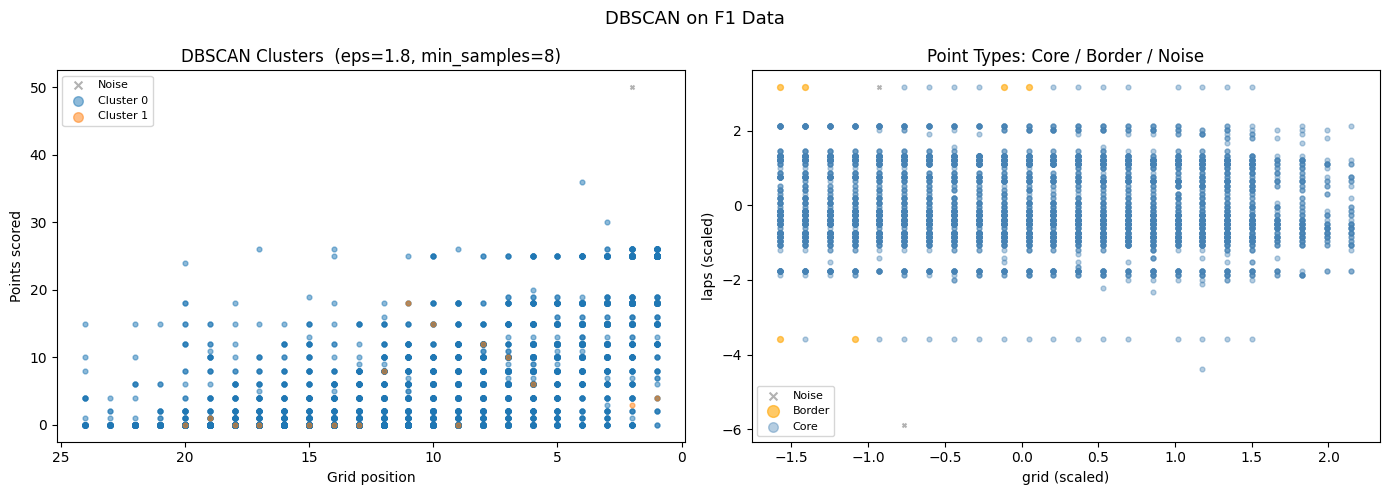

Saved: dbscan_result.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unique_labels = sorted(set(db_final.labels_))
palette = plt.cm.tab10.colors   # up to 10 distinct colours

ax = axes[0]
for label in unique_labels:
    mask = df['dbscan_label'] == label
    if label == -1:
        ax.scatter(df.loc[mask, 'grid'], df.loc[mask, 'points'],
                   c='black', s=8, alpha=0.3, label='Noise', marker='x')
    else:
        c = palette[label % len(palette)]
        ax.scatter(df.loc[mask, 'grid'], df.loc[mask, 'points'],
                   color=c, s=12, alpha=0.5, label=f'Cluster {label}')

ax.set_xlabel("Grid position")
ax.set_ylabel("Points scored")
ax.set_title(f"DBSCAN Clusters  (eps={EPS}, min_samples={MIN_SAMP})")
ax.invert_xaxis()
ax.legend(fontsize=8, markerscale=2)

ax2 = axes[1]
ax2.scatter(X_scaled[noise_mask, 0],  X_scaled[noise_mask, 1],
            c='black', s=8, alpha=0.3, label='Noise', marker='x')
ax2.scatter(X_scaled[border_mask, 0], X_scaled[border_mask, 1],
            c='orange', s=18, alpha=0.6, label='Border')
ax2.scatter(X_scaled[core_mask, 0],   X_scaled[core_mask, 1],
            c='steelblue', s=12, alpha=0.4, label='Core')

ax2.set_xlabel("grid (scaled)")
ax2.set_ylabel("laps (scaled)")
ax2.set_title("Point Types: Core / Border / Noise")
ax2.legend(fontsize=8, markerscale=2)

plt.suptitle("DBSCAN on F1 Data", fontsize=13)
plt.tight_layout()
plt.savefig("dbscan_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dbscan_result.png")


In [12]:
noise_df = df[df['dbscan_label'] == -1][
    ['driver_name', 'year', 'grid', 'points', 'laps', 'fastestLapSpeed']
].copy()

print(f"Total noise points: {len(noise_df)}")
print()
print("Sample noise entries (unusual race results):")
print(noise_df.sample(min(15, len(noise_df)), random_state=42).to_string(index=False))
print()

Total noise points: 3

Sample noise entries (unusual race results):
    driver_name  year  grid  points  laps  fastestLapSpeed
Romain Grosjean  2013   6.0     0.0     8          183.879
 Lewis Hamilton  2014   2.0    50.0    55          189.342
   Sergio Pérez  2020   5.0    25.0    87          224.599



In [13]:
df_clusters = df[df['dbscan_label'] != -1].copy()

print("=== DBSCAN Cluster Profiles (mean values) ===")
profile = df_clusters.groupby('dbscan_label')[FEATURES + ['podium']].mean().round(2)
print(profile)
print()

mask = df['dbscan_label'] != -1
if mask.sum() > 1 and len(set(db_final.labels_[mask])) >= 2:
    sil = silhouette_score(X_scaled[mask], db_final.labels_[mask])
    print(f"Silhouette score (non-noise points): {sil:.3f}")

print()
print("=== Step 3 Complete! ===")
print("Key DBSCAN advantages over K-Means:")
print("  1. No need to choose K — cluster count is discovered automatically")
print("  2. Can find non-spherical, irregular shaped clusters")
print("  3. Explicitly labels outliers as noise (-1) instead of forcing them into a cluster")
print()

=== DBSCAN Cluster Profiles (mean values) ===
               grid   laps  points  fastestLapSpeed  podium
dbscan_label                                               
0             10.72  59.31    5.79           204.87    0.17
1             11.38  87.00    4.81           223.49    0.12

Silhouette score (non-noise points): 0.321

=== Step 3 Complete! ===
Key DBSCAN advantages over K-Means:
  1. No need to choose K — cluster count is discovered automatically
  2. Can find non-spherical, irregular shaped clusters
  3. Explicitly labels outliers as noise (-1) instead of forcing them into a cluster

